# 당뇨병 예측 프로젝트 - 탐색적 데이터 분석 (EDA)\n",
    "\n",
    "**데이터**: CDC BRFSS 생활습관/건강지표 설문 (HuggingFace)  \n",
    "**목표**: 모델링 전에 데이터 구조, 분포, 클래스 불균형, 피처 간 관계를 파악한다.\n",
    "\n",
    "**분석 순서**\n",
    "1. 데이터 로드\n",
    "2. 기본 정보 확인 (타입, 통계량, 결측치)\n",
    "3. 타겟 변수 분포 (클래스 불균형)\n",
    "4. 피처 분포\n",
    "5. 타겟과 피처 간 관계

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 기본 한글 폰트
plt.rcParams['axes.unicode_minus'] = False      # 마이너스 기호 깨짐 방지

## 1. 데이터 로드

In [2]:
import pandas as pd
import seaborn as sns
from pathlib import Path

DATA_PATH = Path('data/diabetes.parquet')

if DATA_PATH.exists():
    df = pd.read_parquet(DATA_PATH)
    print(f'로컬 캐시 로드: {DATA_PATH}')
else:
    from datasets import load_dataset
    DATA_PATH.parent.mkdir(exist_ok=True)
    ds = load_dataset('Bena345/cdc-diabetes-health-indicators')
    df = ds['train'].to_pandas()
    df.to_parquet(DATA_PATH, index=False)
    print(f'HuggingFace 다운로드 후 저장: {DATA_PATH}')

print(f'Shape: {df.shape}')
df.head()

로컬 캐시 로드: data\diabetes.parquet
Shape: (194825, 23)


,ID,BMI,PhysHlth,Age,HighBP,HighChol,CholCheck,Smoker,Stroke,HeartDiseaseorAttack,...,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,DiffWalk,Sex,Education,Income,Diabetes_binary
0,114414,29.0,0.0,65 to 69,0,1,1,0,0,0,...,0,1,1,Poor,0,0,0,6,7,Non-Diabetic
1,168896,32.0,0.0,80 or older,1,1,1,0,0,0,...,0,1,0,Poor,0,0,0,Some College Degree,4,Non-Diabetic
2,68354,25.0,5.0,65 to 69,1,0,1,1,0,0,...,0,1,0,Fair,0,0,1,6,2,Non-Diabetic
3,121194,24.0,0.0,80 or older,1,0,1,0,0,0,...,0,1,0,Very Good,0,1,0,Advanced Degree,5,Non-Diabetic
4,141150,31.0,0.0,25 to 29,0,0,1,0,0,1,...,0,1,0,Very Good,5,0,0,6,6,Diabetic


## 2. 기본 정보 확인

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 194825 entries, 0 to 194824
Data columns (total 23 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   ID                    194825 non-null  int64  
 1   BMI                   194825 non-null  float32
 2   PhysHlth              194825 non-null  float32
 3   Age                   194825 non-null  str    
 4   HighBP                194825 non-null  str    
 5   HighChol              194825 non-null  str    
 6   CholCheck             194825 non-null  str    
 7   Smoker                194825 non-null  str    
 8   Stroke                194825 non-null  str    
 9   HeartDiseaseorAttack  194825 non-null  str    
 10  PhysActivity          194825 non-null  str    
 11  Fruits                194825 non-null  str    
 12  Veggies               194825 non-null  str    
 13  HvyAlcoholConsump     194825 non-null  str    
 14  AnyHealthcare         194825 non-null  str    
 15  NoDocbcCost

**해석**
- 총 194,825행 × 23컬럼
- 수치형: `BMI`, `PhysHlth` 2개 / 나머지 19개는 문자열(str) → 모델링 시 인코딩 필요
- `ID`는 식별자이므로 피처에서 제외
- 결측치 없음 → 별도의 결측 처리 불필요

**해석**
- `BMI` 평균 28.4 → 과체중 기준(25) 초과, 표본 전반이 과체중 경향
- `BMI` 최댓값 98 → 극단값 존재하지만 실제 측정값이므로 제거하지 않음
- `PhysHlth` 중앙값 0, 평균 4.2 → 대부분의 응답자가 신체적 불편 없음(0), 일부가 높은 값 → 우편향 분포

In [4]:
df.describe()

,ID,BMI,PhysHlth
count,194825.000000,194825.000000,194825.000000
mean,126918.099217,28.379520,4.238055
std,73215.216847,6.605747,8.723742
min,0.000000,12.000000,0.000000
25%,63575.000000,24.000000,0.000000
50%,126880.000000,27.000000,0.000000
75%,190372.000000,31.000000,3.000000
max,253678.000000,98.000000,30.000000


In [5]:
# 결측치 확인
df.isnull().sum()

ID                      0
BMI                     0
PhysHlth                0
Age                     0
HighBP                  0
HighChol                0
CholCheck               0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
DiffWalk                0
Sex                     0
Education               0
Income                  0
Diabetes_binary         0
dtype: int64

## 3. 타겟 변수 분포 (클래스 불균형 확인)

**해석**
- Non-Diabetic 86.1% / Diabetic 13.9% → **심각한 클래스 불균형**
- 이 상태에서 Accuracy만 평가하면 "전부 Non-Diabetic 예측"만 해도 86% 달성 → **무의미한 지표**
- 모델링 시 클래스 불균형 처리 필수: `class_weight='balanced'`, `is_unbalance=True`, `scale_pos_weight` 등
- 평가지표는 **AUC, Recall, F1** 위주로 판단해야 함

In [6]:
TARGET = 'Diabetes_binary'
FEATURES = [c for c in df.columns if c not in ('ID', TARGET)]
print(f'타겟 컬럼: {TARGET}')
print(f'피처 수: {len(FEATURES)}')
print(df[TARGET].value_counts())
print(f'\n비율:\n{df[TARGET].value_counts(normalize=True).round(3)}')

타겟 컬럼: Diabetes_binary
피처 수: 21
Diabetes_binary
Non-Diabetic    167679
Diabetic         27146
Name: count, dtype: int64

비율:
Diabetes_binary
Non-Diabetic    0.861
Diabetic        0.139
Name: proportion, dtype: float64


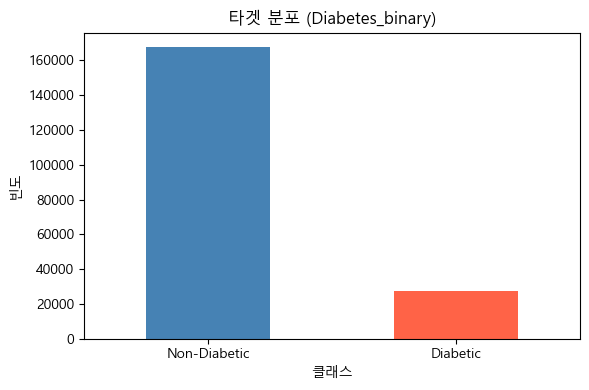

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
df[TARGET].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'tomato'])
ax.set_title('타겟 분포 (Diabetes_binary)')
ax.set_xlabel('클래스')
ax.set_ylabel('빈도')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

**해석**
- `BMI`: 정규분포에 가깝지만 오른쪽 꼬리 존재 (고도비만 포함)
- `PhysHlth`: 0에 집중된 우편향 분포 → 대부분 "건강하지 않은 날"이 없다고 응답, 트리 계열 모델은 이 분포에 강건함

**해석**
- `HighBP`(고혈압): 고혈압 그룹에서 당뇨 비율 뚜렷하게 높음 → 강한 연관성
- `HighChol`(고콜레스테롤): 고콜레스테롤 그룹에서도 당뇨 비율 상승
- `GenHlth`(전반적 건강상태): 건강상태가 나쁠수록 당뇨 비율 단조 증가 → 순서형 피처로 활용 가능
- 이런 패턴들은 임상적으로 타당하며, 해당 피처들이 모델에서도 높은 중요도를 보일 것으로 예상

## 4. 피처 분포 확인

**해석**
- 당뇨 그룹의 BMI 분포가 비당뇨 그룹보다 오른쪽으로 치우쳐 있음
- BMI가 높을수록 당뇨 위험 증가하는 경향이 명확 → 모델에서 가장 중요한 피처 중 하나로 예상 (실제로 모델링 결과 피처 중요도 1위)

**해석**
- `BMI` ↔ 당뇨 상관계수 0.217, `PhysHlth` ↔ 당뇨 0.171
- 수치형 피처 2개만으로는 전체 피처의 영향력을 판단할 수 없음
- 범주형 피처들의 중요도는 모델 학습 후 **피처 중요도(feature importance)** 로 확인 → `02_modeling.ipynb` 참고

---
**EDA 종합 결론**
1. **클래스 불균형** (86:14) → 모델링 시 반드시 처리 필요
2. **결측치 없음** → 전처리 부담 없음
3. **대부분 범주형** → OrdinalEncoder로 인코딩 후 모델 입력
4. **BMI, GenHlth, HighBP** 등이 당뇨와 뚜렷한 연관성 → 피처 중요도 높을 것으로 예상

In [8]:
print(f'피처 수: {len(FEATURES)}')
print(FEATURES)

피처 수: 21
['BMI', 'PhysHlth', 'Age', 'HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'DiffWalk', 'Sex', 'Education', 'Income']


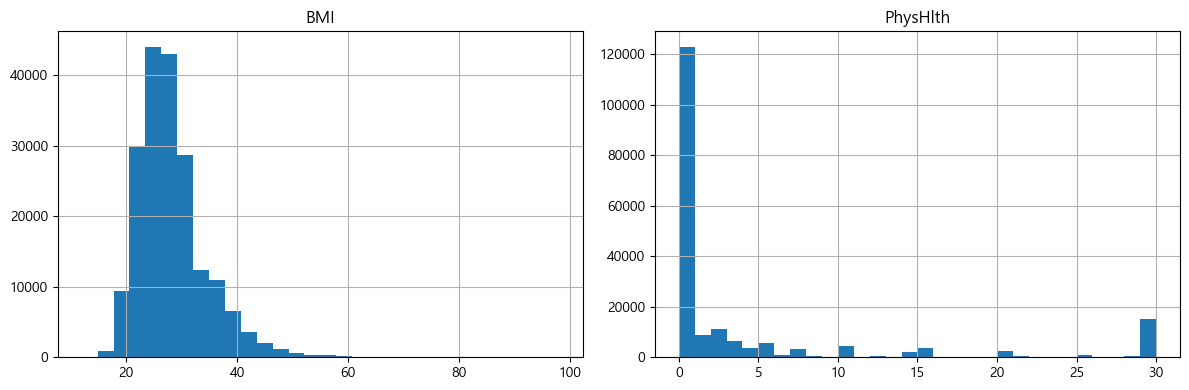

In [9]:
# 수치형 피처 히스토그램 (BMI, PhysHlth)
num_cols = df[FEATURES].select_dtypes(include='number').columns
if len(num_cols) > 0:
    df[num_cols].hist(figsize=(12, 4), bins=30)
    plt.tight_layout()
    plt.show()

C:\Users\wlsdy\AppData\Local\Temp\ipykernel_10944\325139629.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df[FEATURES].select_dtypes(include='object').columns[:6]


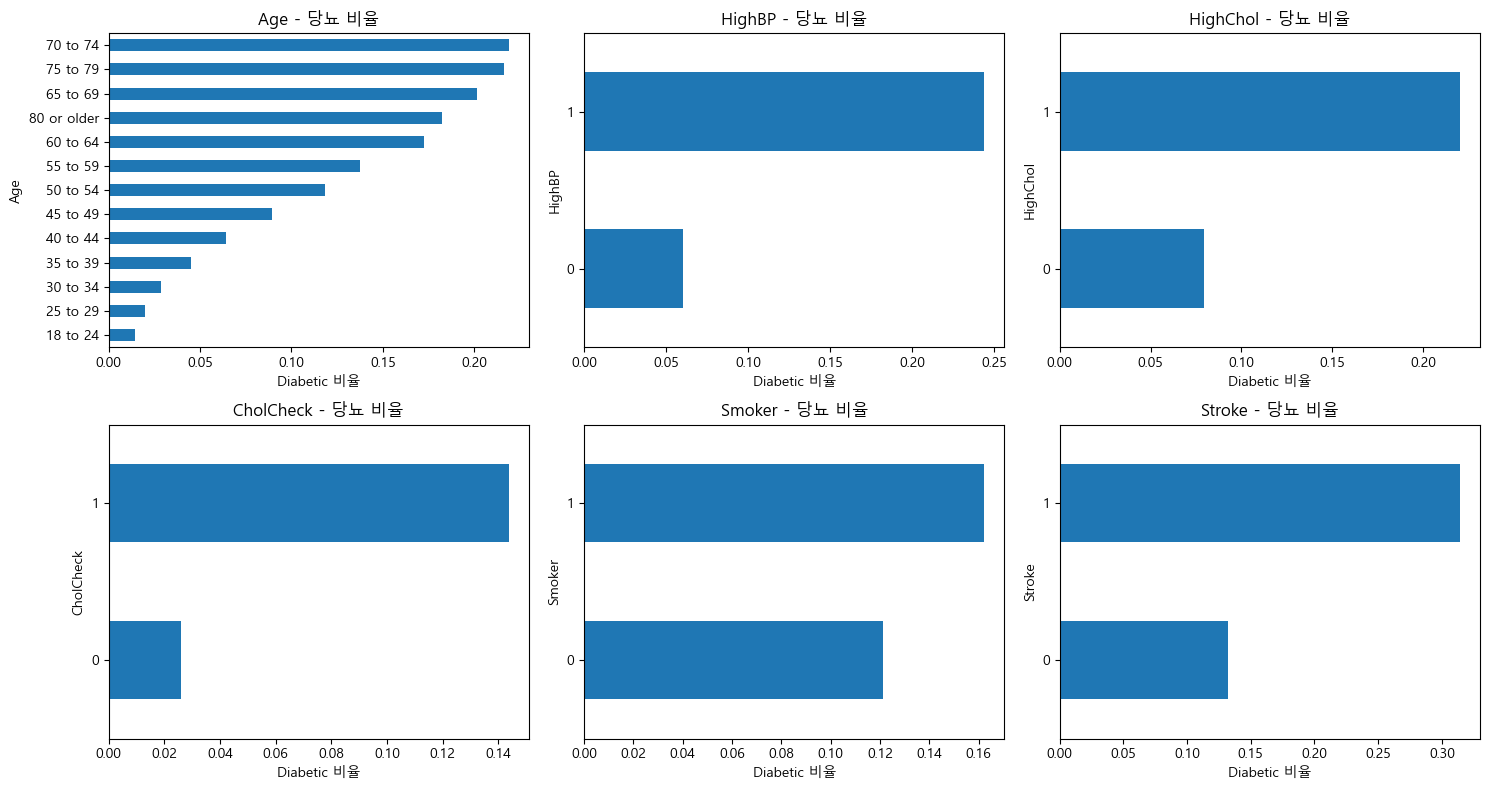

In [10]:
# 범주형 피처별 당뇨 비율 (상위 6개)
cat_cols = df[FEATURES].select_dtypes(include='object').columns[:6]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, cat_cols):
    cross = df.groupby(col)[TARGET].value_counts(normalize=True).unstack(fill_value=0)
    if 'Diabetic' in cross.columns:
        cross['Diabetic'].sort_values().plot(kind='barh', ax=ax)
        ax.set_title(f'{col} - 당뇨 비율')
        ax.set_xlabel('Diabetic 비율')
plt.tight_layout()
plt.show()

## 5. 수치형 피처와 타겟 간 관계

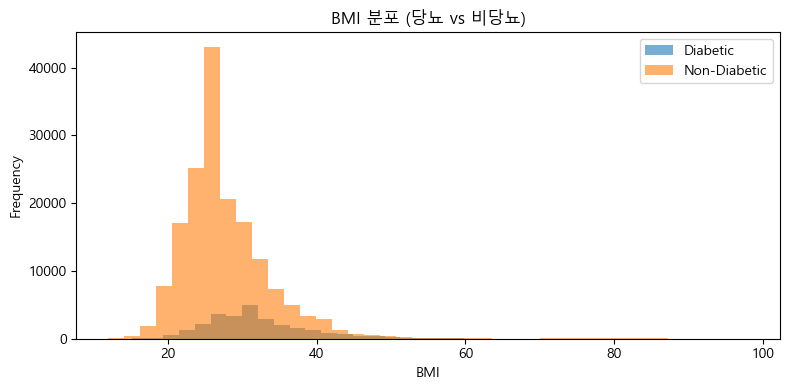

In [11]:
# BMI 분포 (당뇨 vs 비당뇨)
fig, ax = plt.subplots(figsize=(8, 4))
for label, grp in df.groupby(TARGET)['BMI']:
    grp.plot(kind='hist', bins=40, alpha=0.6, ax=ax, label=label)
ax.set_title('BMI 분포 (당뇨 vs 비당뇨)')
ax.set_xlabel('BMI')
ax.legend()
plt.tight_layout()
plt.show()

In [12]:
# 수치형 상관관계 (BMI, PhysHlth)
import numpy as np
num_df = df[list(num_cols)].copy()
num_df[TARGET] = (df[TARGET] == 'Diabetic').astype(int)
corr = num_df.corr()
print('수치형 피처 상관관계:')
print(corr)

수치형 피처 상관관계:
                      BMI  PhysHlth  Diabetes_binary
BMI              1.000000  0.121747         0.216507
PhysHlth         0.121747  1.000000         0.171136
Diabetes_binary  0.216507  0.171136         1.000000
